In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score, accuracy_score
from collections import Counter
import re
import os
import warnings
warnings.filterwarnings('ignore')

In [5]:
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

In [10]:
print("جارٍ تحميل البيانات...")

# تحديد مسار الملف داخل فولدر models
file_path = os.path.join("1_model", "spam.csv") 

try:
    # قراءة الملف وتغيير أسماء الأعمدة في خطوة واحدة
    df = pd.read_csv(file_path, encoding="latin-1")[["v1", "v2"]]
    df.columns = ["label", "text"]
    
    print("✅ تم تحميل البيانات بنجاح!")
    print(f"عدد الرسائل في البيانات: {len(df)} رسالة") # سطر إضافي للتأكيد
    
except FileNotFoundError:
    print(f"❌ خطأ: ملف spam.csv مش موجود جوه فولدر models!")
    print("تأكد إن الفولدر اسمه models وإن الملف جواه بالاسم ده.")

جارٍ تحميل البيانات...
✅ تم تحميل البيانات بنجاح!
عدد الرسائل في البيانات: 5572 رسالة


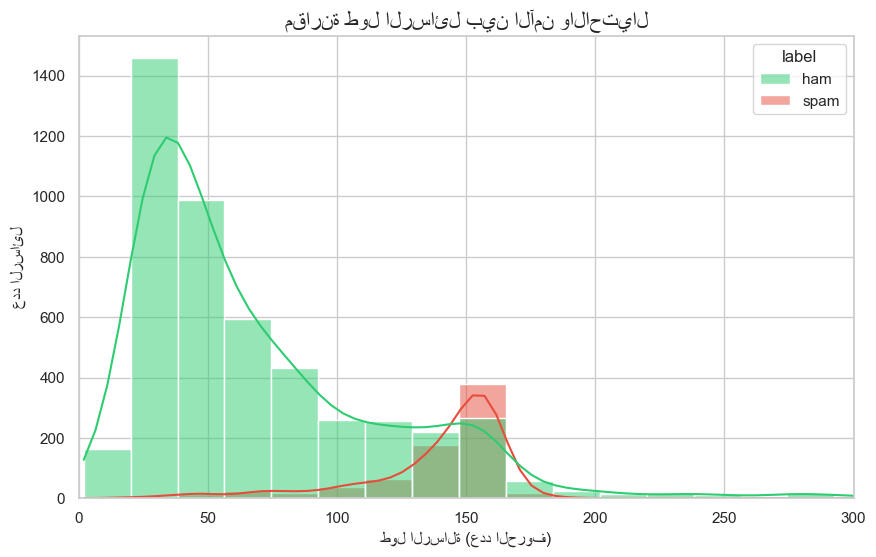

In [11]:
df['msg_length'] = df['text'].apply(len)

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='msg_length', hue='label', bins=50, kde=True, 
             palette={'ham': '#2ecc71', 'spam': '#e74c3c'})
plt.title('مقارنة طول الرسائل بين الآمن والاحتيال', fontsize=16)
plt.xlabel('طول الرسالة (عدد الحروف)')
plt.ylabel('عدد الرسائل')
plt.xlim(0, 300) # عملنا زووم على الرسائل اللي طولها لحد 300 حرف
plt.show()

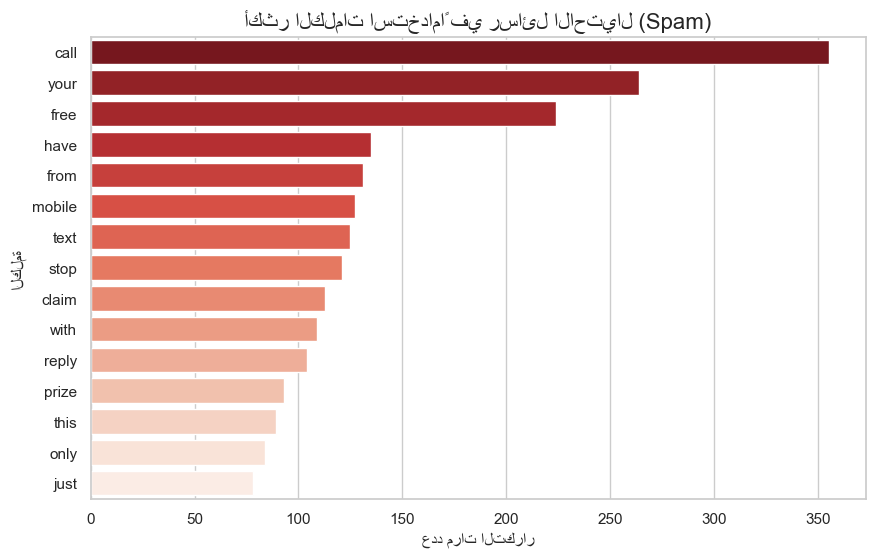

In [17]:
# ---------------------------------------------------------
# الرسمة التالتة: أكثر الكلمات استخداماً (Bar Chart بديل للسحابة)
# ---------------------------------------------------------
# تجميع وتنظيف نصوص الاحتيال
spam_text = " ".join(df[df['label'] == 'spam']['text'].astype(str)).lower()
spam_words = re.findall(r'\b[a-z]{4,}\b', spam_text) # كلمات أكبر من 3 حروف

# حساب أكثر 15 كلمة تكراراً
top_spam_words = Counter(spam_words).most_common(15)
top_words_df = pd.DataFrame(top_spam_words, columns=['Word', 'Frequency'])

plt.figure(figsize=(10, 6))
sns.barplot(data=top_words_df, x='Frequency', y='Word', palette='Reds_r')
plt.title('أكثر الكلمات استخداماً في رسائل الاحتيال (Spam)', fontsize=16)
plt.xlabel('عدد مرات التكرار')
plt.ylabel('الكلمة')
plt.show()

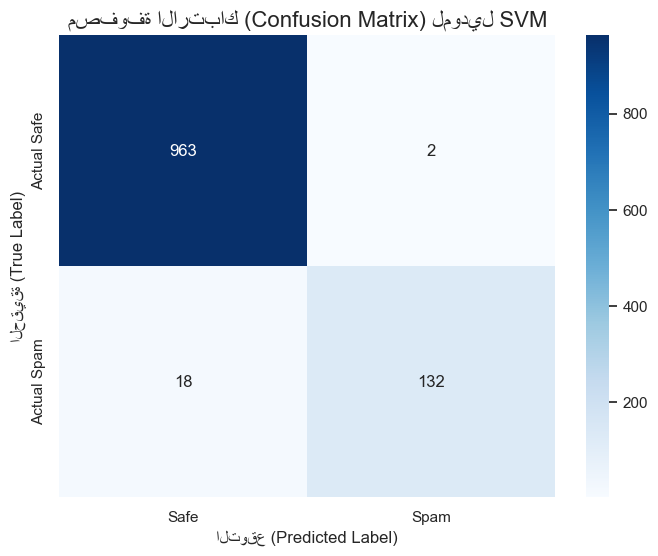

In [18]:
# ---------------------------------------------------------
# الرسمة الرابعة: مصفوفة الارتباك (Confusion Matrix) 
# ---------------------------------------------------------
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['label_num'], test_size=0.2, random_state=42)

vectorizer = TfidfVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

model = LinearSVC()
model.fit(X_train_vec, y_train)
y_pred = model.predict(X_test_vec)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Safe', 'Spam'], 
            yticklabels=['Actual Safe', 'Actual Spam'])
plt.title('مصفوفة الارتباك (Confusion Matrix) لموديل SVM', fontsize=16)
plt.ylabel('الحقيقة (True Label)')
plt.xlabel('التوقع (Predicted Label)')
plt.show()

جارٍ تنفيذ تجارب الـ Hyperparameters...


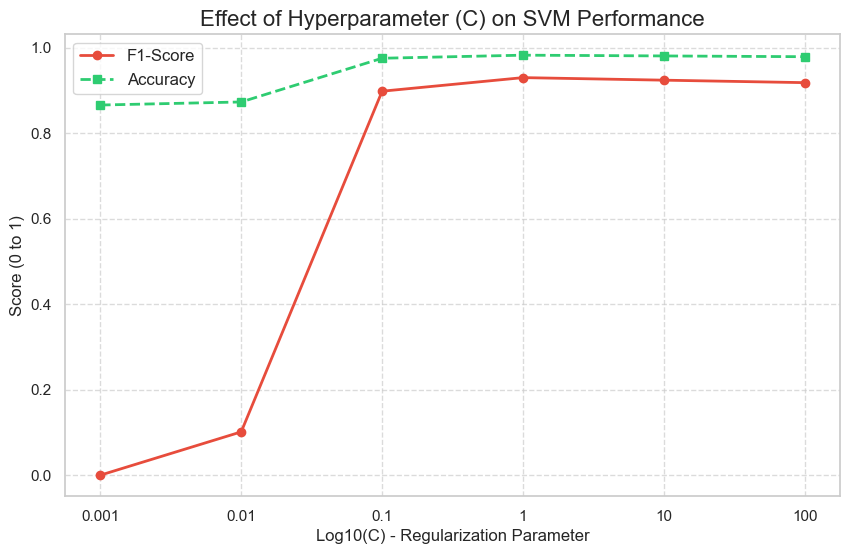

✅ أفضل قيمة للـ C هي: 1 (F1-Score: 0.9296)


In [22]:
print("جارٍ تنفيذ تجارب الـ Hyperparameters...")

# قيم الـ C اللي هنجربها (من صغير جداً لكبير)
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
f1_scores = []
accuracies = []

# تدريب الموديل بكل قيمة وحساب النتيجة
for c in C_values:
    model = LinearSVC(C=c, max_iter=2000, random_state=42)
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)
    
    f1_scores.append(f1_score(y_test, y_pred))
    accuracies.append(accuracy_score(y_test, y_pred))

# رسم تأثير الـ Hyperparameter
plt.figure(figsize=(10, 6))
plt.plot(np.log10(C_values), f1_scores, marker='o', linestyle='-', color='#e74c3c', label='F1-Score', linewidth=2)
plt.plot(np.log10(C_values), accuracies, marker='s', linestyle='--', color='#2ecc71', label='Accuracy', linewidth=2)

plt.title('Effect of Hyperparameter (C) on SVM Performance', fontsize=16)
plt.xlabel('Log10(C) - Regularization Parameter', fontsize=12)
plt.ylabel('Score (0 to 1)', fontsize=12)
plt.xticks(np.log10(C_values), labels=C_values) # إظهار القيم الأصلية على المحور
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# طباعة أفضل نتيجة
best_c = C_values[np.argmax(f1_scores)]
print(f"✅ أفضل قيمة للـ C هي: {best_c} (F1-Score: {max(f1_scores):.4f})")